# Cleaning Data (IDN Version)
Plan:
1. Melakukan pengecekan dataset (Apa yang missing, duplikat, ID unik, dll)
2. Analisa dataset (EDA, visualisasi data)
3. Pengambilan Keputusan
4. Eksekusi 

- Plan ini bisa berubah, tergantung kondisi

## Persiapan Library

In [2]:
# Library yang dibutuhkan

import pandas as pd # untuk manipulasi data
import numpy as np # untuk operasi matematika
import matplotlib.pyplot as plt # untuk visualisasi data
import seaborn as sns # untuk visualisasi data yang lebih menarik

## Persiapan dan Pengecekan Dataset
---
Jadi ya gitu wkwkw

In [3]:
# Membaca dataset
train = "../raw/train.csv"
test = "../raw/test.csv"
sub = "../raw/gender_submission.csv" # Untuk nanti

train_df = pd.read_csv(train) # Fokus ke data train dulu
test_df = pd.read_csv(test)
sub_df = pd.read_csv(sub)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check distribusi data train

print("===== Distribusi data =====")
print(train_df['Survived'].value_counts())

print("\nSelisih antara 0 dan 1:",
      train_df['Survived'].value_counts()[0] - train_df['Survived'].value_counts()[1])

===== Distribusi data =====
Survived
0    549
1    342
Name: count, dtype: int64

Selisih antara 0 dan 1: 207


In [5]:
# Check missing values

print("===== Missing Values =====")
train_df.isnull().sum()

===== Missing Values =====


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Check data
print("===== Data Info =====")
train_df.info()

===== Data Info =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Check data duplikasi
print("===== Data Types =====")
train_df.duplicated().sum()

===== Data Types =====


np.int64(0)

In [8]:
# Checck data shape

print("===== Data Shape =====")
print("Train data shape:", train_df.shape)

===== Data Shape =====
Train data shape: (891, 12)


### REKAPITULASI STEP I
---
- Adanya missing data pada kolom "age", "cabin" dan "Embarked" (hanya 2 missing)
- Selisih label survival dengan tidak yaitu 207 baris
- Perlu menganalisa dataset lebih spesifik
- Ini untuk saat ini (Wednesday, 18 June 2026)

## Analisa Dataset
---
<b>Mari kita lihat data secara visual dan data statistik</b>
<br>
Plan : 
1. Melihat ditribusi label 0 dan 1
2. Visualisasi histogram
3. Menampilkan data statistik
4. Melihat korelasi masing-masing fitur pada label

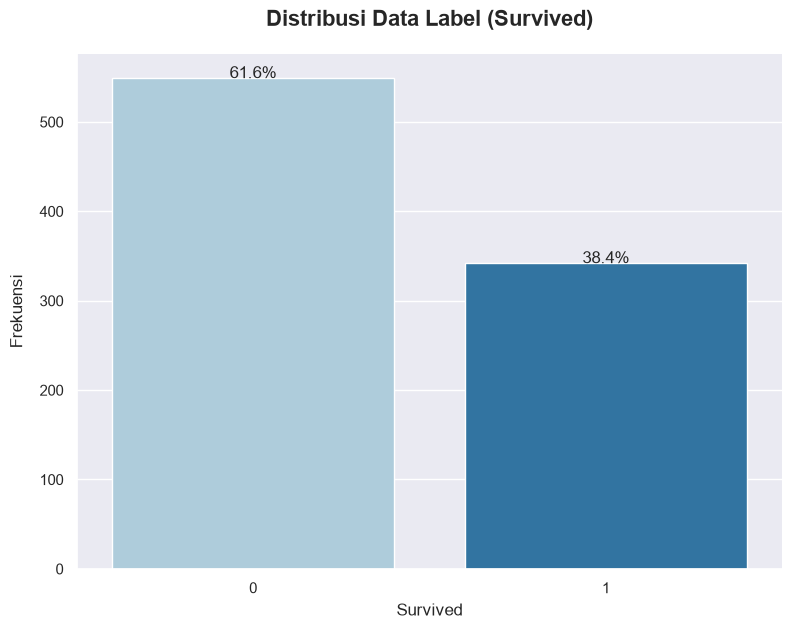

In [9]:
# Check distribusi data label menggunakan matplotlib dan seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x="Survived",
    data=train_df,
    palette="Paired",
    hue="Survived",
    legend=False
)

total = len(train_df)

for p in ax.patches:
    count=p.get_height()

    percentage = 100 * count / total

    ax.annotate(
        f'{percentage:.1f}%',
        (
            p.get_x() + p.get_width()/2,
            count
        ),
        ha='center'
    )

# Untuk menampilkan frekuensi data pada setiap bar
sns.despine()

plt.tight_layout()
plt.title(
    "Distribusi Data Label (Survived)",
    fontsize=16,
    fontweight="bold",
    pad=20
    )
plt.xlabel("Survived", labelpad=5)
plt.ylabel("Frekuensi", labelpad=10)

plt.show()

<h3><b>INTERPRETASI DARI VISUALISASI DISTRIBUSI LABEL</b></h3>
<p style= "text-align: justify;">
Berdasarkan visualisasi ditribusi di atas, kelas 0 memiliki proporsi data sebesar 61.6%, sedangkan kelas 1 memiliki proporsi sebesar 38.4%.
Meskipun kelas 0 mendominasi kelas 1, bisa dikatakan bahwa perbandingan kedua kelas cukup seimbang dan tidak menunjukkan adanya class imbalance
yang ekstrem. Oleh karena itu, diperkirakan ketidakseimbangan class tidak menjadi masalah utama dalam pelatihan model.
</p>



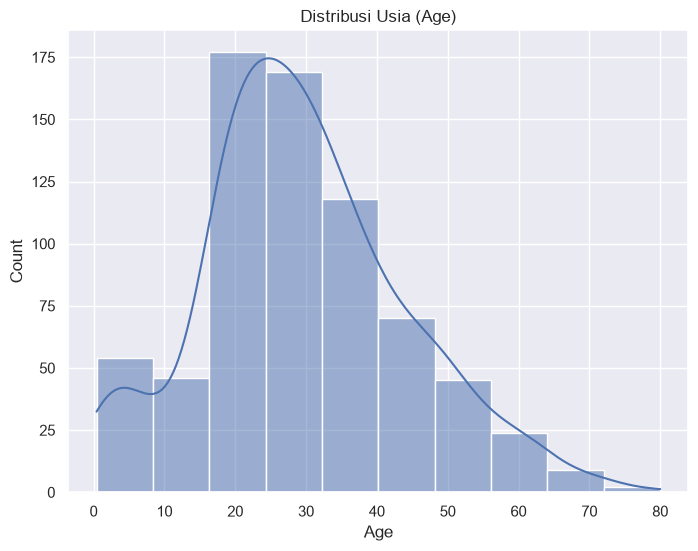

In [10]:
# Check data numberik "age" secara histogram
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x="Age",
    bins=10,
    kde=True,
)

plt.title("Distribusi Usia (Age)")
plt.show()